Autores: Josep Pérez Segura, Raul Rodríguez López Rey
# Tarea B3-T1


## 1. Importación de datos

Descargamos datos históricos de **BTCUSDT** (Bitcoin vs USDT) desde la API pública de Binance.

- **Intervalo**: velas de 5 minutos
- **Periodo**: últimos 3 años (marzo 2023 – marzo 2026)
- **Endpoint**: `GET /api/v3/klines` (sin API key, máximo 1000 velas por request)
- **Cache**: los datos se guardan en CSV local (`data/BTCUSDT_5m_3y.csv`) para no re-descargar en ejecuciones posteriores

Referencia: Lopez de Prado (2018), *Advances in Financial Machine Learning* – recomienda usar datos de alta frecuencia para construir barras alternativas (dollar bars, volume bars, tick bars).

In [ ]:
%pip install requests pandas numpy matplotlib tqdm --quiet

In [4]:
import datetime
import time
from pathlib import Path

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

pd.set_option("display.max_columns", None)

In [5]:
# --- Configuración ---
SYMBOL = "BTCUSDT"
INTERVAL = "5m"
BASE_URL = "https://api.binance.com/api/v3/klines"

START_DATE = datetime.datetime(2023, 3, 16)
END_DATE = datetime.datetime(2026, 3, 16)
START_MS = int(START_DATE.timestamp() * 1000)
END_MS = int(END_DATE.timestamp() * 1000)

LIMIT = 1000  # máximo por request
SLEEP_BETWEEN = 0.05  # 50 ms entre requests (evitar rate limiting)

DATA_DIR = Path("data")
CSV_PATH = DATA_DIR / f"{SYMBOL}_{INTERVAL}_3y.csv"

print(f"Periodo: {START_DATE.date()} -> {END_DATE.date()}")
print(f"Intervalo: {INTERVAL}")
print(f"Requests estimados: ~{(END_MS - START_MS) // (LIMIT * 5 * 60 * 1000) + 1}")

Periodo: 2023-03-16 -> 2026-03-16
Intervalo: 5m
Requests estimados: ~316


In [6]:
def fetch_klines(symbol, interval, start_ms, end_ms, limit=1000):
    """Descarga velas de Binance con paginación automática."""
    session = requests.Session()
    all_klines = []
    current_ms = start_ms

    # Estimar número de requests para la barra de progreso
    interval_ms = 5 * 60 * 1000  # 5 minutos en ms
    estimated_requests = (end_ms - start_ms) // (limit * interval_ms) + 1

    pbar = tqdm(total=estimated_requests, desc="Descargando velas")

    while current_ms < end_ms:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": current_ms,
            "endTime": end_ms,
            "limit": limit,
        }

        resp = session.get(BASE_URL, params=params)

        # Manejo de rate limiting
        if resp.status_code in (429, 418):
            retry_after = int(resp.headers.get("Retry-After", 5))
            print(f"Rate limited. Esperando {retry_after}s...")
            time.sleep(retry_after)
            continue

        resp.raise_for_status()
        data = resp.json()

        if not data:
            break

        all_klines.extend(data)

        # Avanzar: close_time del último registro + 1 ms
        current_ms = data[-1][6] + 1
        pbar.update(1)

        time.sleep(SLEEP_BETWEEN)

    pbar.close()
    print(f"Total velas descargadas: {len(all_klines):,}")
    return all_klines

In [7]:
if CSV_PATH.exists():
    print(f"Cargando datos desde cache local: {CSV_PATH}")
    df = pd.read_csv(CSV_PATH, parse_dates=["open_time", "close_time"])
else:
    DATA_DIR.mkdir(exist_ok=True)
    print("Descargando datos de Binance API...")
    raw = fetch_klines(SYMBOL, INTERVAL, START_MS, END_MS, LIMIT)

    columns = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_volume", "num_trades",
        "taker_buy_base_vol", "taker_buy_quote_vol", "ignore",
    ]
    df = pd.DataFrame(raw, columns=columns)

    # Conversión de tipos
    numeric_cols = ["open", "high", "low", "close", "volume",
                    "quote_volume", "taker_buy_base_vol", "taker_buy_quote_vol"]
    df[numeric_cols] = df[numeric_cols].astype(float)
    df["num_trades"] = df["num_trades"].astype(int)
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms")
    df.drop(columns=["ignore"], inplace=True)

    # Eliminar duplicados y ordenar
    df.drop_duplicates(subset=["open_time"], inplace=True)
    df.sort_values("open_time", inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Filtrar al rango exacto
    df = df[(df["open_time"] >= str(START_DATE)) &
            (df["open_time"] < str(END_DATE))]
    df.reset_index(drop=True, inplace=True)

    # Guardar cache
    df.to_csv(CSV_PATH, index=False)
    size_mb = CSV_PATH.stat().st_size / 1e6
    print(f"Guardado en {CSV_PATH} ({len(df):,} filas, {size_mb:.1f} MB)")

print(f"DataFrame cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")

Cargando datos desde cache local: data\BTCUSDT_5m_3y.csv
DataFrame cargado: 315,621 filas x 11 columnas


In [8]:
# --- Verificación y exploración ---
print(f"Periodo: {df['open_time'].min()} -> {df['open_time'].max()}")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Shape: {df.shape}\n")

display(df.describe())
print()
display(df.head())

# Comprobar huecos temporales
deltas = df["open_time"].diff().dt.total_seconds().dropna()
gaps = deltas[deltas != 300]  # 300s = 5 min
print(f"\nHuecos temporales (intervalos != 5 min): {len(gaps)} de {len(deltas)}")
if len(gaps) > 0:
    print("Distribución de huecos (segundos):")
    display(gaps.value_counts().head(10))

Periodo: 2023-03-16 00:00:00 -> 2026-03-15 23:00:00
Memoria: 27.8 MB
Shape: (315621, 11)



,open_time,open,high,low,close,volume,close_time,quote_volume,num_trades,taker_buy_base_vol,taker_buy_quote_vol
count,315621,315621.000000,315621.000000,315621.000000,315621.000000,315621.000000,315621,3.156210e+05,315621.000000,315621.000000,3.156210e+05
mean,2024-09-14 00:09:22.648872448,69255.541521,69313.958161,69195.897637,69255.695029,115.645287,2024-09-14 00:14:22.647815936,6.870378e+06,9905.474449,56.840639,3.369067e+06
min,2023-03-16 00:00:00,24137.270000,24236.990000,24123.000000,24135.210000,0.000000,2023-03-16 00:04:59.999000,0.000000e+00,0.000000,0.000000,0.000000e+00
25%,2023-12-15 00:45:00,41715.350000,41742.450000,41691.100000,41715.740000,33.691160,2023-12-15 00:49:59.999000064,2.087278e+06,2925.000000,14.762420,9.225653e+05
50%,2024-09-14 00:10:00,67511.510000,67581.100000,67441.250000,67511.970000,63.345200,2024-09-14 00:14:59.999000064,3.883182e+06,5652.000000,29.759390,1.815473e+06
75%,2025-06-14 23:35:00,95587.300000,95677.940000,95500.000000,95587.300000,123.017120,2025-06-14 23:39:59.999000064,7.585146e+06,11731.000000,60.573720,3.720478e+06
max,2026-03-15 23:00:00,126011.180000,126199.630000,125868.130000,126011.180000,9082.013470,2026-03-15 23:04:59.999000,5.588519e+08,711259.000000,4199.910420,2.663202e+08
std,NaN,29800.183396,29822.074886,29777.898507,29800.076017,207.730483,NaN,1.040135e+07,12382.882283,105.927382,5.361188e+06


,open_time,open,high,low,close,volume,close_time,quote_volume,num_trades,taker_buy_base_vol,taker_buy_quote_vol
0,2023-03-16 00:00:00,24285.66,24330.00,24244.85,24320.43,1297.15515,2023-03-16 00:04:59.999,3.150841e+07,37888,703.57672,1.709184e+07
1,2023-03-16 00:05:00,24319.86,24324.99,24261.40,24267.11,1031.22185,2023-03-16 00:09:59.999,2.505415e+07,31881,494.99527,1.202650e+07
2,2023-03-16 00:10:00,24267.11,24276.87,24200.00,24275.30,2103.30631,2023-03-16 00:14:59.999,5.096738e+07,46576,983.26865,2.382859e+07
3,2023-03-16 00:15:00,24275.30,24337.49,24275.21,24327.09,1143.01401,2023-03-16 00:19:59.999,2.778655e+07,32854,609.75281,1.482329e+07
4,2023-03-16 00:20:00,24327.09,24384.12,24326.14,24362.41,1363.56637,2023-03-16 00:24:59.999,3.321088e+07,36718,738.49945,1.798709e+07



Huecos temporales (intervalos != 5 min): 1 de 315620
Distribución de huecos (segundos):


open_time
5100.0    1
Name: count, dtype: int64

## 2. Barras alternativas: Dollar Bars, Volume Bars y Tick Bars

Las barras basadas en tiempo (time bars) presentan propiedades estadísticas indeseables: autocorrelación, heterocedasticidad y distribuciones no normales. Lopez de Prado (2018, Cap. 2) propone muestrear los datos usando **barras alternativas** que se cierran al alcanzar un umbral acumulado:

- **Tick Bars**: se cierra una barra cada N operaciones (trades). Muestrean según la actividad del mercado.
- **Volume Bars**: se cierra una barra cada V unidades de volumen (BTC). Normalizan la información por volumen negociado.
- **Dollar Bars**: se cierra una barra cada D dólares negociados (quote volume en USDT). Son las más robustas según MLdP, ya que normalizan por valor económico real.

Al usar velas de 5 min como proxy, cada vela aporta: `num_trades` (ticks), `volume` (BTC), y `quote_volume` (USDT). Acumulamos estos valores y generamos una nueva barra OHLCV cada vez que se supera el umbral.

Compararemos **3 umbrales distintos** para cada tipo de barra para ilustrar el efecto del parámetro.

In [9]:
def make_bars(df, metric_col, threshold):
    """
    Genera barras alternativas agrupando filas hasta que la suma acumulada
    de `metric_col` supera `threshold`.

    Parámetros:
        df: DataFrame con columnas open_time, open, high, low, close, volume,
            quote_volume, num_trades y la columna `metric_col`.
        metric_col: columna a acumular ('num_trades', 'volume', 'quote_volume').
        threshold: valor umbral para cerrar cada barra.

    Retorna:
        DataFrame con barras OHLCV + timestamp.
    """
    bars = []
    cum_metric = 0.0
    open_price = df.iloc[0]["open"]
    high_price = -np.inf
    low_price = np.inf
    cum_volume = 0.0
    cum_quote_volume = 0.0
    cum_trades = 0
    bar_start = df.iloc[0]["open_time"]

    for _, row in df.iterrows():
        high_price = max(high_price, row["high"])
        low_price = min(low_price, row["low"])
        cum_volume += row["volume"]
        cum_quote_volume += row["quote_volume"]
        cum_trades += row["num_trades"]
        cum_metric += row[metric_col]

        if cum_metric >= threshold:
            bars.append({
                "open_time": bar_start,
                "close_time": row["close_time"],
                "open": open_price,
                "high": high_price,
                "low": low_price,
                "close": row["close"],
                "volume": cum_volume,
                "quote_volume": cum_quote_volume,
                "num_trades": cum_trades,
            })
            # Reset
            cum_metric = 0.0
            cum_volume = 0.0
            cum_quote_volume = 0.0
            cum_trades = 0
            high_price = -np.inf
            low_price = np.inf
            open_price = row["close"]
            bar_start = row["close_time"]

    return pd.DataFrame(bars)

In [10]:
# --- Calcular estadísticas para elegir umbrales razonables ---
print("Estadísticas por vela de 5 min:")
print(f"  num_trades  -> media: {df['num_trades'].mean():,.0f}, mediana: {df['num_trades'].median():,.0f}")
print(f"  volume (BTC)-> media: {df['volume'].mean():,.1f}, mediana: {df['volume'].median():,.1f}")
print(f"  quote_vol ($)-> media: {df['quote_volume'].mean():,.0f}, mediana: {df['quote_volume'].median():,.0f}")

# Umbrales: elegidos para generar ~5K, ~15K y ~50K barras aprox.
total_trades = df["num_trades"].sum()
total_volume = df["volume"].sum()
total_dollar = df["quote_volume"].sum()

tick_thresholds = [
    int(total_trades / 50_000),
    int(total_trades / 15_000),
    int(total_trades / 5_000),
]
volume_thresholds = [
    round(total_volume / 50_000, 0),
    round(total_volume / 15_000, 0),
    round(total_volume / 5_000, 0),
]
dollar_thresholds = [
    round(total_dollar / 50_000, -3),
    round(total_dollar / 15_000, -3),
    round(total_dollar / 5_000, -3),
]

print(f"\nUmbrales Tick Bars:   {tick_thresholds} trades")
print(f"Umbrales Volume Bars: {volume_thresholds} BTC")
print(f"Umbrales Dollar Bars: {dollar_thresholds} USDT")

Estadísticas por vela de 5 min:
  num_trades  -> media: 9,905, mediana: 5,652
  volume (BTC)-> media: 115.6, mediana: 63.3
  quote_vol ($)-> media: 6,870,378, mediana: 3,883,182

Umbrales Tick Bars:   [62527, 208425, 625275] trades
Umbrales Volume Bars: [np.float64(730.0), np.float64(2433.0), np.float64(7300.0)] BTC
Umbrales Dollar Bars: [np.float64(43369000.0), np.float64(144562000.0), np.float64(433687000.0)] USDT


In [11]:
# --- Generar las barras alternativas ---
print("Generando barras... (puede tardar unos segundos por cada umbral)\n")

bar_results = {}

for label, col, thresholds in [
    ("Tick Bars", "num_trades", tick_thresholds),
    ("Volume Bars", "volume", volume_thresholds),
    ("Dollar Bars", "quote_volume", dollar_thresholds),
]:
    bar_results[label] = {}
    for th in thresholds:
        bars_df = make_bars(df, col, th)
        bar_results[label][th] = bars_df
        print(f"  {label} (umbral={th:,.0f}): {len(bars_df):,} barras")
    print()

Generando barras... (puede tardar unos segundos por cada umbral)

  Tick Bars (umbral=62,527): 42,504 barras
  Tick Bars (umbral=208,425): 14,172 barras
  Tick Bars (umbral=625,275): 4,901 barras

  Volume Bars (umbral=730): 40,285 barras
  Volume Bars (umbral=2,433): 13,803 barras
  Volume Bars (umbral=7,300): 4,845 barras

  Dollar Bars (umbral=43,369,000): 41,354 barras
  Dollar Bars (umbral=144,562,000): 13,994 barras
  Dollar Bars (umbral=433,687,000): 4,878 barras



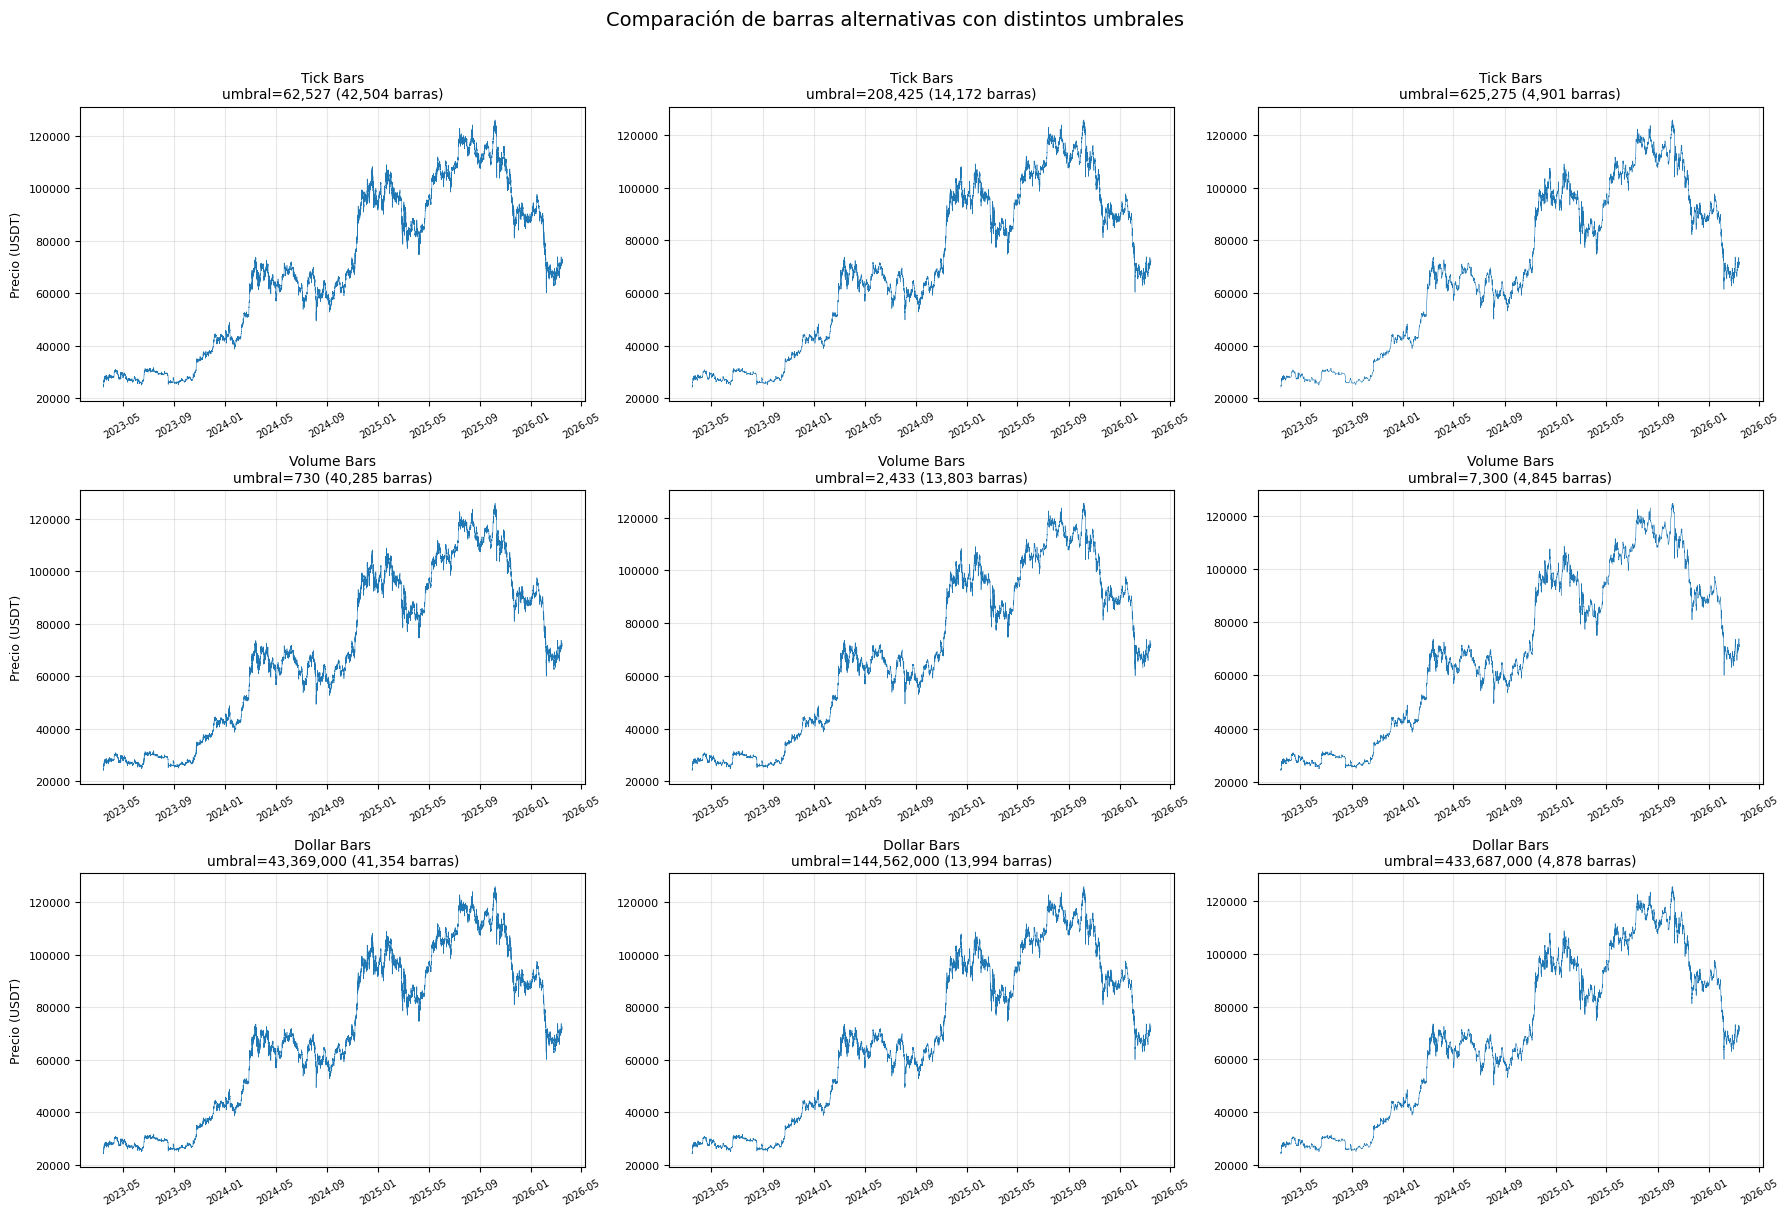

In [12]:
# --- Gráfica comparativa: precio close para cada tipo de barra ---
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for row_idx, (bar_type, thresholds_dict) in enumerate(bar_results.items()):
    for col_idx, (th, bars_df) in enumerate(thresholds_dict.items()):
        ax = axes[row_idx, col_idx]
        ax.plot(bars_df["open_time"], bars_df["close"], linewidth=0.4)
        ax.set_title(f"{bar_type}\numbral={th:,.0f} ({len(bars_df):,} barras)", fontsize=10)
        ax.tick_params(axis="x", rotation=30, labelsize=7)
        ax.tick_params(axis="y", labelsize=8)
        ax.grid(True, alpha=0.3)
        if col_idx == 0:
            ax.set_ylabel("Precio (USDT)", fontsize=9)

fig.suptitle("Comparación de barras alternativas con distintos umbrales", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

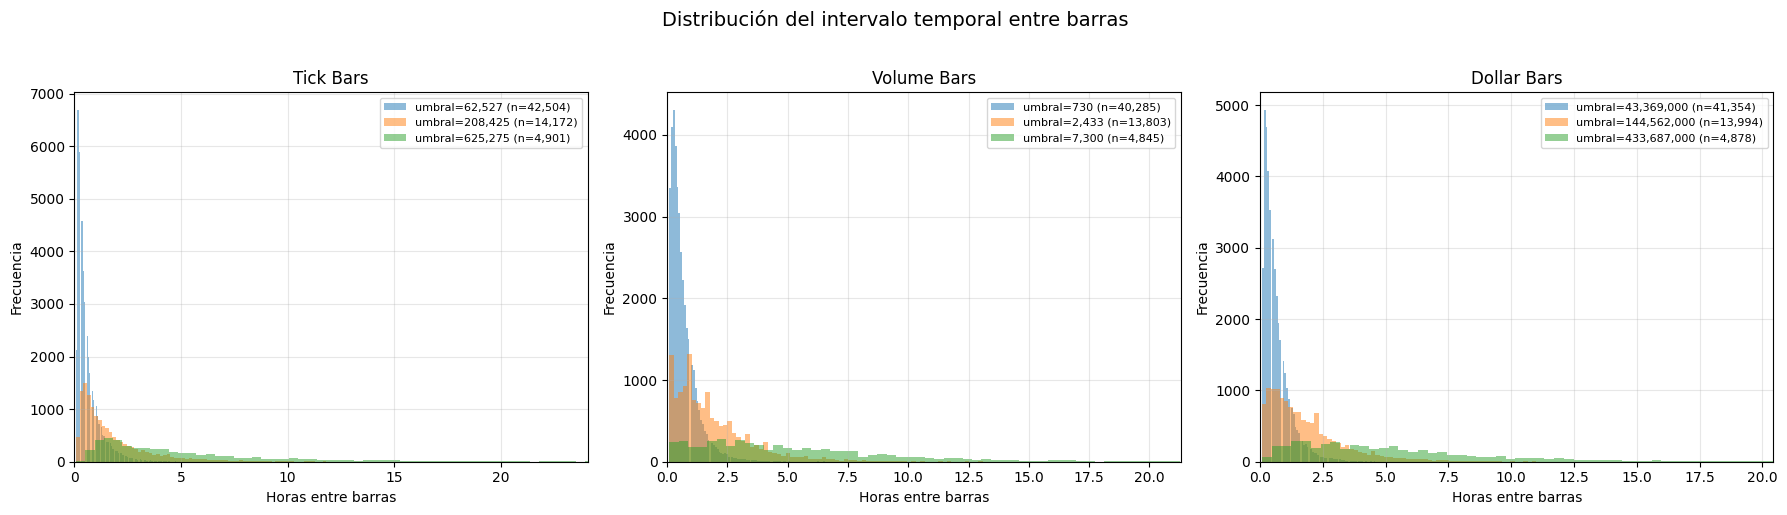

In [13]:
# --- Distribución del intervalo temporal entre barras ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col_idx, (bar_type, thresholds_dict) in enumerate(bar_results.items()):
    ax = axes[col_idx]
    for th, bars_df in thresholds_dict.items():
        dt_hours = bars_df["open_time"].diff().dt.total_seconds().dropna() / 3600
        ax.hist(dt_hours, bins=100, alpha=0.5, label=f"umbral={th:,.0f} (n={len(bars_df):,})")
    ax.set_title(bar_type, fontsize=12)
    ax.set_xlabel("Horas entre barras")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=8)
    ax.set_xlim(0, dt_hours.quantile(0.99))
    ax.grid(True, alpha=0.3)

fig.suptitle("Distribución del intervalo temporal entre barras", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

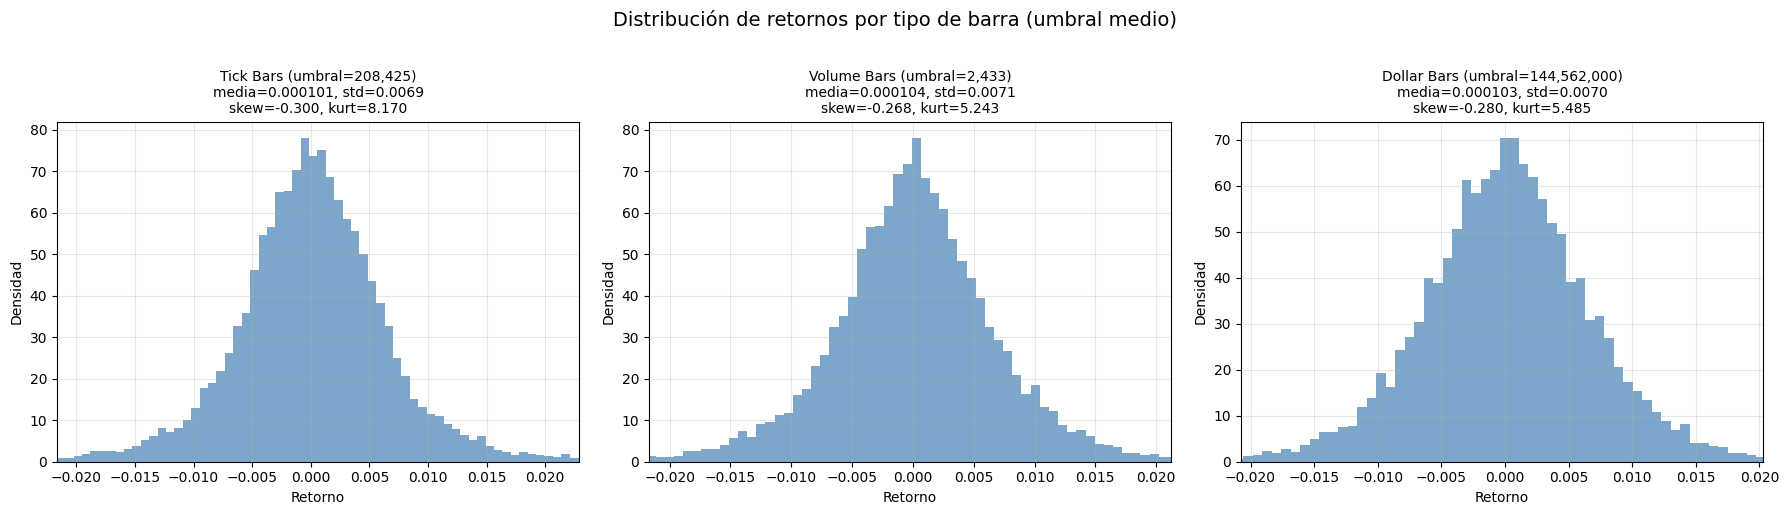


Resumen de retornos (umbral medio de cada tipo):
Tipo              N barras        Media        Std     Skew     Kurt
-----------------------------------------------------------------
Tick Bars           14,172     0.000101     0.0069   -0.300    8.170
Volume Bars         13,803     0.000104     0.0071   -0.268    5.243
Dollar Bars         13,994     0.000103     0.0070   -0.280    5.485


In [14]:
# --- Comparar propiedades estadísticas: retornos de cada tipo de barra ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Usar el umbral medio de cada tipo para la comparación
for col_idx, (bar_type, thresholds_dict) in enumerate(bar_results.items()):
    ax = axes[col_idx]
    thresholds_list = list(thresholds_dict.items())
    # Umbral medio
    th_mid, bars_mid = thresholds_list[1]
    returns = bars_mid["close"].pct_change().dropna()

    ax.hist(returns, bins=200, alpha=0.7, density=True, color="steelblue")
    ax.set_title(f"{bar_type} (umbral={th_mid:,.0f})\n"
                 f"media={returns.mean():.6f}, std={returns.std():.4f}\n"
                 f"skew={returns.skew():.3f}, kurt={returns.kurtosis():.3f}",
                 fontsize=10)
    ax.set_xlabel("Retorno")
    ax.set_ylabel("Densidad")
    ax.set_xlim(returns.quantile(0.005), returns.quantile(0.995))
    ax.grid(True, alpha=0.3)

fig.suptitle("Distribución de retornos por tipo de barra (umbral medio)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Tabla resumen
print("\nResumen de retornos (umbral medio de cada tipo):")
print(f"{'Tipo':<15} {'N barras':>10} {'Media':>12} {'Std':>10} {'Skew':>8} {'Kurt':>8}")
print("-" * 65)
for bar_type, thresholds_dict in bar_results.items():
    th_mid, bars_mid = list(thresholds_dict.items())[1]
    r = bars_mid["close"].pct_change().dropna()
    print(f"{bar_type:<15} {len(bars_mid):>10,} {r.mean():>12.6f} {r.std():>10.4f} {r.skew():>8.3f} {r.kurtosis():>8.3f}")

### Observaciones sobre las barras alternativas

**Efecto del umbral:** A mayor umbral, menos barras se generan y cada barra contiene más información agregada. Umbrales bajos producen más barras (mayor granularidad) pero con menor información por barra.

**Distribución temporal:** A diferencia de las time bars (espaciado fijo de 5 min), las barras alternativas tienen un espaciado temporal **variable**. Se generan más barras en periodos de alta actividad (volatilidad, noticias) y menos en periodos tranquilos. Esto es deseable porque muestrea proporcionalmente a la llegada de nueva información.

**Propiedades estadísticas de los retornos:**
- Las **Dollar Bars** tienden a producir retornos con menor autocorrelación serial y distribuciones más cercanas a la normalidad, ya que normalizan por el valor económico intercambiado.
- Las **Volume Bars** ofrecen un compromiso similar, normalizando por la cantidad de activo negociado.
- Las **Tick Bars** son las más simples conceptualmente, pero pueden ser sensibles a la fragmentación de órdenes.

Para las secciones siguientes, usaremos las **Dollar Bars** con el umbral medio como base, siguiendo la recomendación de Lopez de Prado.

In [15]:
# --- Seleccionar Dollar Bars (umbral medio) para las siguientes secciones ---
dollar_mid_th = list(bar_results["Dollar Bars"].keys())[1]
df_bars = bar_results["Dollar Bars"][dollar_mid_th].copy()
df_bars.reset_index(drop=True, inplace=True)

print(f"Seleccionadas Dollar Bars con umbral = {dollar_mid_th:,.0f} USDT")
print(f"Total barras: {len(df_bars):,}")
display(df_bars.head())

Seleccionadas Dollar Bars con umbral = 144,562,000 USDT
Total barras: 13,994


,open_time,close_time,open,high,low,close,volume,quote_volume,num_trades
0,2023-03-16 00:00:00.000,2023-03-16 00:24:59.999,24285.66,24384.12,24200.00,24362.41,6938.26369,1.685274e+08,185917
1,2023-03-16 00:24:59.999,2023-03-16 00:49:59.999,24362.41,24373.11,24144.87,24234.44,7219.26477,1.750561e+08,190453
2,2023-03-16 00:49:59.999,2023-03-16 01:19:59.999,24234.44,24287.90,24123.00,24135.21,8163.38939,1.977509e+08,234634
3,2023-03-16 01:19:59.999,2023-03-16 01:44:59.999,24135.21,24324.86,24134.51,24263.56,6399.17638,1.551973e+08,180971
4,2023-03-16 01:44:59.999,2023-03-16 02:14:59.999,24263.56,24399.75,24222.33,24379.77,6403.53081,1.557652e+08,181741


## 3. Diferenciación fraccional

En series financieras existe un trade-off entre **estacionariedad** y **memoria**:

- Diferenciar con *d=1* (retornos) hace la serie estacionaria, pero destruye toda la memoria (relación con niveles pasados de precio).
- No diferenciar (*d=0*, precio en niveles) conserva la memoria, pero la serie es no estacionaria y viola supuestos de muchos modelos ML.

Lopez de Prado (2018, Cap. 5) propone la **diferenciación fraccional** con *0 < d < 1*, que permite encontrar el mínimo *d* que hace la serie estacionaria conservando la mayor cantidad de memoria posible.

La serie diferenciada fraccionalmente se obtiene aplicando el operador:

$$\tilde{X}_t = \sum_{k=0}^{\infty} w_k \, X_{t-k}, \quad w_k = -w_{k-1} \frac{d - k + 1}{k}$$

donde los pesos $w_k$ decaen lentamente (se truncan cuando $|w_k| < \tau$, con $\tau = 10^{-5}$ por defecto).

Compararemos varios valores de *d* ∈ {0, 0.2, 0.4, 0.6, 0.8, 1.0} y evaluaremos la estacionariedad con el test ADF.

In [16]:
%pip install statsmodels --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


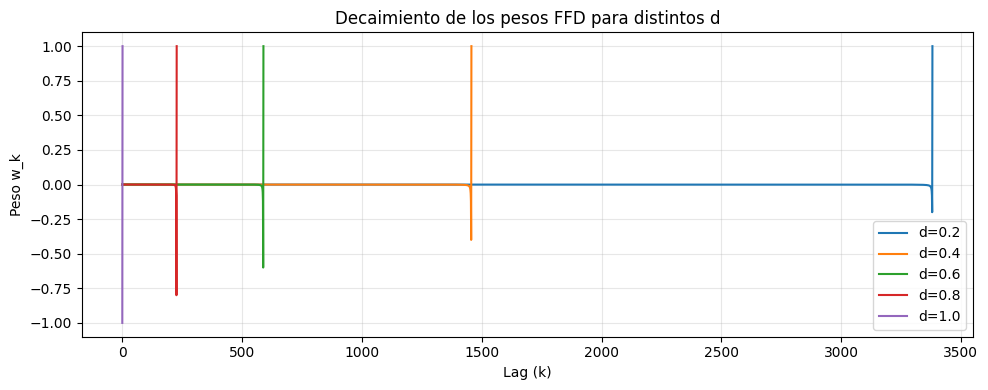

In [17]:
from statsmodels.tsa.stattools import adfuller


def get_weights_ffd(d, threshold=1e-5):
    """
    Calcula los pesos para la diferenciación fraccional (Fixed-Width Window).
    Los pesos se truncan cuando |w_k| < threshold.
    (Lopez de Prado, 2018, Snippet 5.3)
    """
    w = [1.0]
    k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < threshold:
            break
        w.append(w_k)
        k += 1
    return np.array(w[::-1]).reshape(-1, 1)


def frac_diff_ffd(series, d, threshold=1e-5):
    """
    Aplica diferenciación fraccional FFD a una serie.
    (Lopez de Prado, 2018, Snippet 5.4)
    
    Parámetros:
        series: pd.Series con los precios.
        d: orden de diferenciación fraccional.
        threshold: umbral para truncar pesos.
    
    Retorna:
        pd.Series con la serie diferenciada fraccionalmente.
    """
    weights = get_weights_ffd(d, threshold)
    width = len(weights)
    result = {}
    series_values = series.values

    for i in range(width - 1, len(series_values)):
        window = series_values[i - width + 1: i + 1]
        result[series.index[i]] = np.dot(weights.T, window)[0, 0]

    return pd.Series(result, dtype=float)


# Mostrar cómo decaen los pesos para distintos d
fig, ax = plt.subplots(figsize=(10, 4))
for d in [0.2, 0.4, 0.6, 0.8, 1.0]:
    w = get_weights_ffd(d, threshold=1e-5)
    ax.plot(range(len(w)), w.flatten(), label=f"d={d}")
ax.set_xlabel("Lag (k)")
ax.set_ylabel("Peso w_k")
ax.set_title("Decaimiento de los pesos FFD para distintos d")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# --- Aplicar diferenciación fraccional con varios d ---
d_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
close_series = df_bars["close"].reset_index(drop=True)

frac_diff_results = {}
for d in d_values:
    if d == 0.0:
        frac_diff_results[d] = close_series.copy()
    elif d == 1.0:
        frac_diff_results[d] = close_series.diff().dropna()
    else:
        frac_diff_results[d] = frac_diff_ffd(close_series, d)
    print(f"d={d:.1f}: {len(frac_diff_results[d]):,} valores")

d=0.0: 13,994 valores


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

KeyError: 0.2

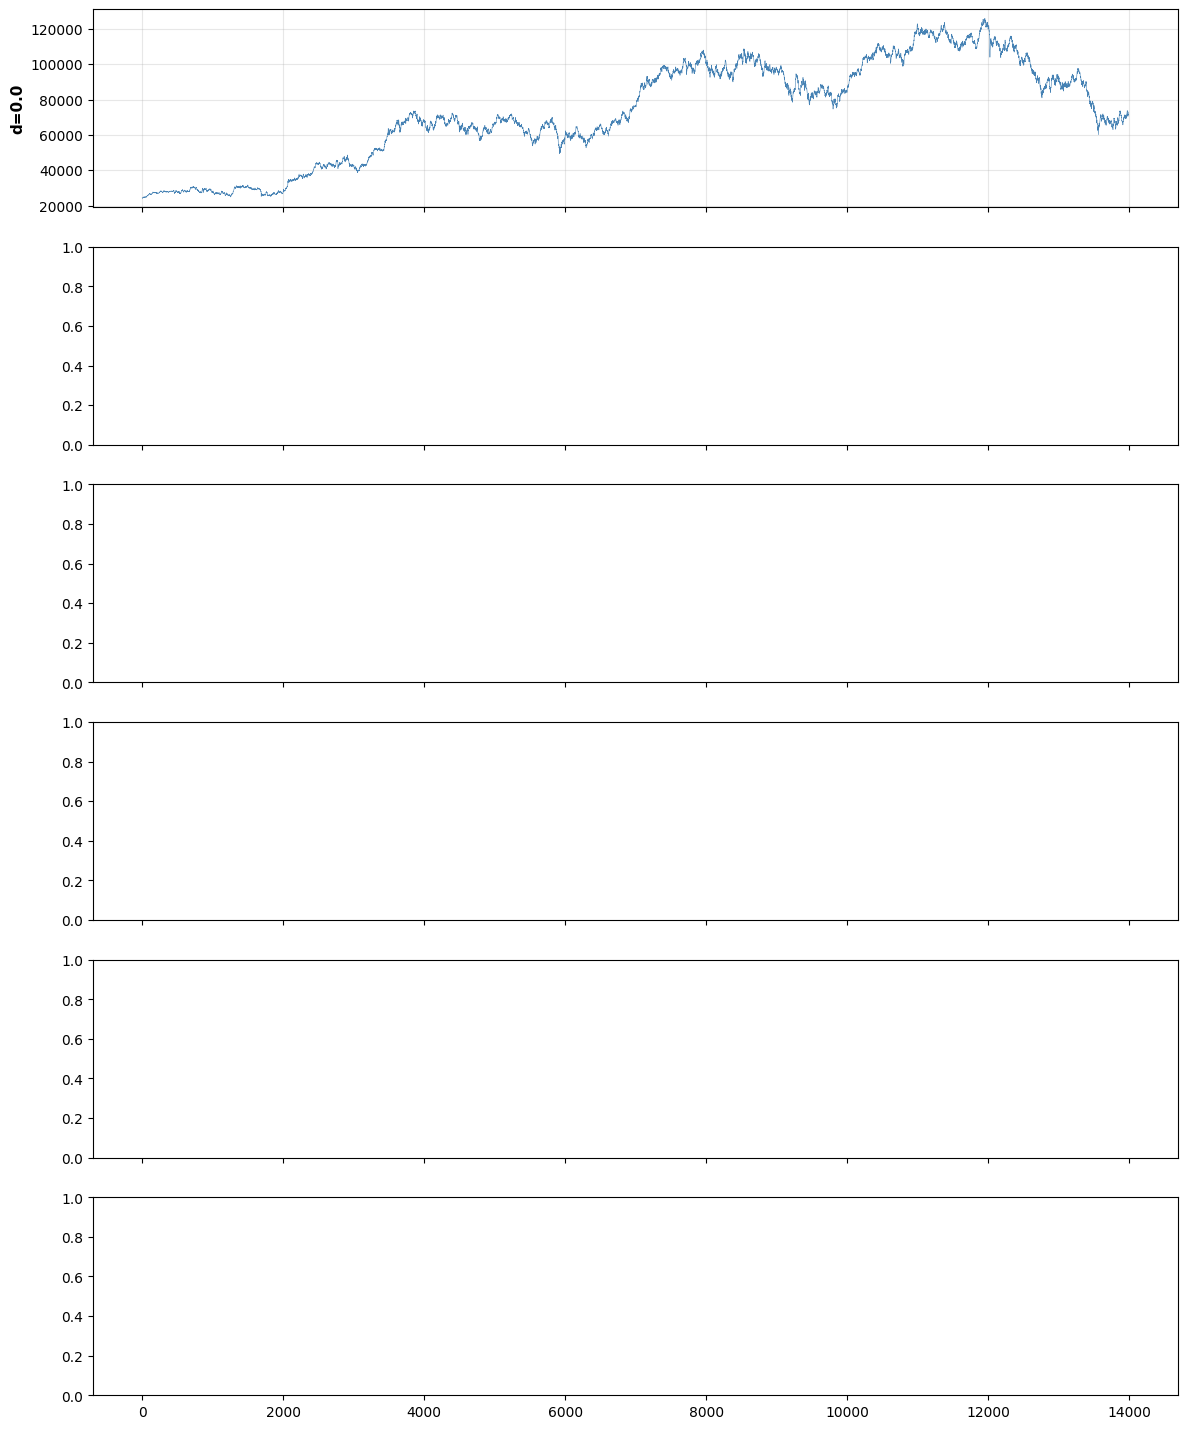

In [19]:
# --- Gráfica: series diferenciadas fraccionalmente ---
fig, axes = plt.subplots(len(d_values), 1, figsize=(14, 3 * len(d_values)), sharex=True)

for i, d in enumerate(d_values):
    s = frac_diff_results[d]
    axes[i].plot(s.values, linewidth=0.4, color="steelblue")
    axes[i].set_ylabel(f"d={d:.1f}", fontsize=11, fontweight="bold")
    axes[i].grid(True, alpha=0.3)

axes[0].set_title("Precio close diferenciado fraccionalmente (Dollar Bars)", fontsize=13)
axes[-1].set_xlabel("Índice de barra")
plt.tight_layout()
plt.show()

In [20]:
# --- Test ADF para cada d: evaluar estacionariedad ---
adf_results = []
for d in d_values:
    s = frac_diff_results[d].dropna()
    adf_stat, p_value, _, _, critical_values, _ = adfuller(s, maxlag=1)
    adf_results.append({
        "d": d,
        "ADF Statistic": adf_stat,
        "p-value": p_value,
        "Estacionaria (p<0.05)": "Sí" if p_value < 0.05 else "No",
        "1% CV": critical_values["1%"],
        "5% CV": critical_values["5%"],
    })

df_adf = pd.DataFrame(adf_results)
display(df_adf)

KeyError: 0.2

In [ ]:
# --- Gráfica: p-value ADF vs d + correlación con serie original ---
fig, ax1 = plt.subplots(figsize=(10, 5))

# p-value ADF
color_adf = "steelblue"
ax1.plot(df_adf["d"], df_adf["p-value"], "o-", color=color_adf, linewidth=2, markersize=8, label="p-value ADF")
ax1.axhline(0.05, color="red", linestyle="--", alpha=0.7, label="Umbral p=0.05")
ax1.set_xlabel("d (orden de diferenciación fraccional)", fontsize=12)
ax1.set_ylabel("p-value ADF", color=color_adf, fontsize=12)
ax1.tick_params(axis="y", labelcolor=color_adf)
ax1.set_ylim(-0.05, max(df_adf["p-value"].max() * 1.1, 0.1))

# Correlación con serie original (eje derecho)
ax2 = ax1.twinx()
color_corr = "darkorange"
correlations = []
for d in d_values:
    s = frac_diff_results[d].dropna()
    common_idx = close_series.index.intersection(s.index)
    corr = close_series.loc[common_idx].corr(s.loc[common_idx])
    correlations.append(corr)

ax2.plot(d_values, correlations, "s--", color=color_corr, linewidth=2, markersize=8, label="Corr. con precio original")
ax2.set_ylabel("Correlación con serie original", color=color_corr, fontsize=12)
ax2.tick_params(axis="y", labelcolor=color_corr)
ax2.set_ylim(-0.1, 1.1)

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=10)

ax1.set_title("Trade-off estacionariedad vs memoria: p-value ADF y correlación vs d", fontsize=13)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Identificar d mínimo estacionario
d_min_stationary = df_adf.loc[df_adf["p-value"] < 0.05, "d"].min()
print(f"\nMínimo d para estacionariedad (p < 0.05): d = {d_min_stationary:.1f}")
print(f"Correlación con precio original en d={d_min_stationary:.1f}: {correlations[d_values.index(d_min_stationary)]:.4f}")

### Observaciones sobre la diferenciación fraccional

**Efecto del parámetro *d*:**
- Con **d=0** (precio en niveles), la serie no es estacionaria (p-value ADF alto), pero conserva toda la memoria (correlación = 1 con el precio original).
- Con **d=1** (retornos), la serie es estacionaria, pero pierde casi toda la relación con los niveles de precio (correlación baja).
- Valores intermedios como **d=0.2 o d=0.4** logran estacionariedad (p-value < 0.05) manteniendo una correlación significativa con la serie original. Este es el punto óptimo que busca MLdP.

**Gráfica de pesos FFD:** Los pesos para d pequeños decaen lentamente (memoria larga), mientras que para d→1 se concentran en los primeros lags (memoria corta). Esto explica visualmente por qué la diferenciación fraccional conserva más información del pasado.

**Recomendación:** Usar el **mínimo *d*** que logre estacionariedad como feature para modelos ML, en lugar de retornos simples (d=1).